# **LOAD & EDA MNIST**

## Load & Split Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.MNIST(root='./data_mnist', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data_mnist', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.16MB/s]


In [2]:
import numpy as np
from torch.utils.data import Subset

# --- Stratified Split ---
# Setiap kelas dibagi rata: 5000 sampel untuk training, 1000 untuk validation.
# Total: 10 kelas x 5000 = 50.000 training, 10 kelas x 1000 = 10.000 validation.
train_size = 50000
val_size = 10000
num_classes = 10
train_per_class = train_size // num_classes   # 5000
val_per_class = val_size // num_classes       # 1000

# Ambil dataset asli (aman walau sel ini dijalankan ulang)
base_dataset = train_set.dataset if hasattr(train_set, 'dataset') else train_set
targets = base_dataset.targets.numpy()

rng = np.random.default_rng(42)  # seed agar hasil split reproducible

train_indices, val_indices = [], []
for c in range(num_classes):
    class_idx = np.where(targets == c)[0]
    rng.shuffle(class_idx)  # acak sampel dalam kelas
    train_indices.extend(class_idx[:train_per_class])
    val_indices.extend(class_idx[train_per_class:train_per_class + val_per_class])

train_set = Subset(base_dataset, train_indices)
val_set = Subset(base_dataset, val_indices)

# --- Verifikasi ---
print(f"Jumlah sampel training: {len(train_set)}")
print(f"Jumlah sampel validation: {len(val_set)}")
print(f"Jumlah sampel test: {len(test_set)}")

train_targets = targets[train_indices]
val_targets = targets[val_indices]
print(f"\n{'Kelas':<25}{'Train':>8}{'Val':>8}")
for c, name in enumerate(base_dataset.classes):
    print(f"{name:<25}{(train_targets == c).sum():>8}{(val_targets == c).sum():>8}")

Jumlah sampel training: 50000
Jumlah sampel validation: 8862
Jumlah sampel test: 10000

Kelas                       Train     Val
0 - zero                     5000     923
1 - one                      5000    1000
2 - two                      5000     958
3 - three                    5000    1000
4 - four                     5000     842
5 - five                     5000     421
6 - six                      5000     918
7 - seven                    5000    1000
8 - eight                    5000     851
9 - nine                     5000     949


In [3]:
import numpy as np

# train_set adalah Subset (hasil random_split) -> tidak punya .data / .targets.
# Ambil data & label dari dataset asli, lalu pilih sesuai indeks Subset.
base_dataset = train_set.dataset
subset_indices = np.asarray(train_set.indices)
images = base_dataset.data[subset_indices].numpy()
labels = base_dataset.targets[subset_indices].numpy()

# 3. Ratakan (flatten) gambar 2D (28x28) menjadi array 1D (784 piksel)
# Menggunakan -1 otomatis mendeteksi jumlah total baris (50,000)
X_flattened = images.reshape(images.shape[0], -1)

# 4. Masukkan ke dalam Pandas DataFrame
df = pd.DataFrame(X_flattened)
df.info()

# 5. Tambahkan kolom label ke dalam DataFrame agar data lengkap
df['label'] = labels

# Intip hasil data
print(f"Ukuran DataFrame: {df.shape}")
print(df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 784 entries, 0 to 783
dtypes: uint8(784)
memory usage: 37.4 MB
Ukuran DataFrame: (50000, 785)
   0  1  2  3  4  5  6  7  8  9  ...  775  776  777  778  779  780  781  782  \
0  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
1  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
2  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
3  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
4  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
5  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
6  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
7  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
8  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
9  0  0  0  0  0  0  

In [4]:
# Menghitung sparsity atau angka 0 di semua kolom dan baris
zero_number = (df == 0).sum().sum()
print(f"Zero number: {zero_number}")

sparsity = zero_number / (60000 * 785)
# Menampilkan sparsity dalam bentuk persen
print(f"Sparsity: {sparsity * 100:.2f}%")

Zero number: 31661171
Sparsity: 67.22%


In [5]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
count,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.0,50000.0,50000.0,50000.00000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.100980,0.046600,0.018200,0.013260,0.001160,0.0,0.0,0.0,0.0,4.50000
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.287362,2.857305,1.712941,1.479638,0.259384,0.0,0.0,0.0,0.0,2.87231
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,2.00000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,4.50000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,7.00000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,253.000000,253.000000,254.000000,58.000000,0.0,0.0,0.0,0.0,9.00000


## Distribusi Label Dataset

       Kelas  Jumlah
0   0 - zero    5000
1    1 - one    5000
2    2 - two    5000
3  3 - three    5000
4   4 - four    5000
5   5 - five    5000
6    6 - six    5000
7  7 - seven    5000
8  8 - eight    5000
9   9 - nine    5000


/tmp/ipykernel_1534/3023036596.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts.values, palette='viridis')


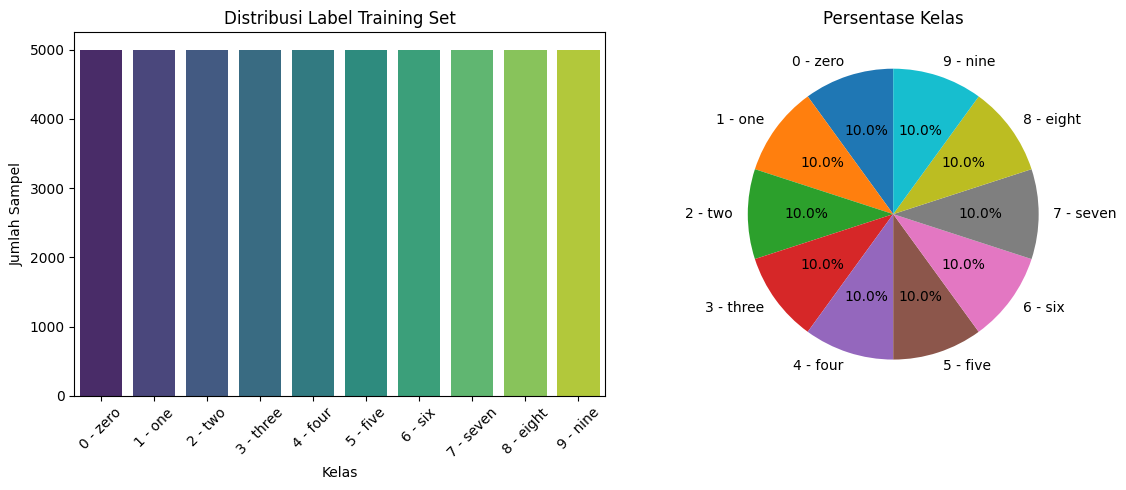

In [6]:
# Hitung frekuensi per kelas
class_counts = df['label'].value_counts().sort_index()
class_names = train_set.dataset.classes

# Tampilkan dalam DataFrame
label_dist = pd.DataFrame({
    'Kelas': class_names,
    'Jumlah': class_counts.values
})
print(label_dist)

# Visualisasi
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sns.barplot(x=class_names, y=class_counts.values, palette='viridis')
plt.title('Distribusi Label Training Set')
plt.ylabel('Jumlah Sampel')
plt.xlabel('Kelas')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=class_names, autopct='%1.1f%%', startangle=90)
plt.title('Persentase Kelas')

plt.tight_layout()
plt.show()

## Statistik Dasar Dataset

In [7]:
print(f"jumlah training sample: {len(train_set)}")
print(f"jumlah test sample: {len(test_set)}")
print(f"dimensi gambar: {train_set[0][0].shape}")
print(f"jumlah kelas: {len(train_set.dataset.classes)}")

jumlah training sample: 50000
jumlah test sample: 10000
dimensi gambar: torch.Size([1, 28, 28])
jumlah kelas: 10


In [8]:
print(f"Rata-rata sampel per kelas: {class_counts.mean():.0f}")
print(f"Std dev sampel per kelas: {class_counts.std():.2f}")
print(f"Dataset seimbang? {'Ya' if class_counts.std() < 100 else 'Tidak sempurna'}")

Rata-rata sampel per kelas: 5000
Std dev sampel per kelas: 0.00
Dataset seimbang? Ya


## Visualiasi Gambar Dataset

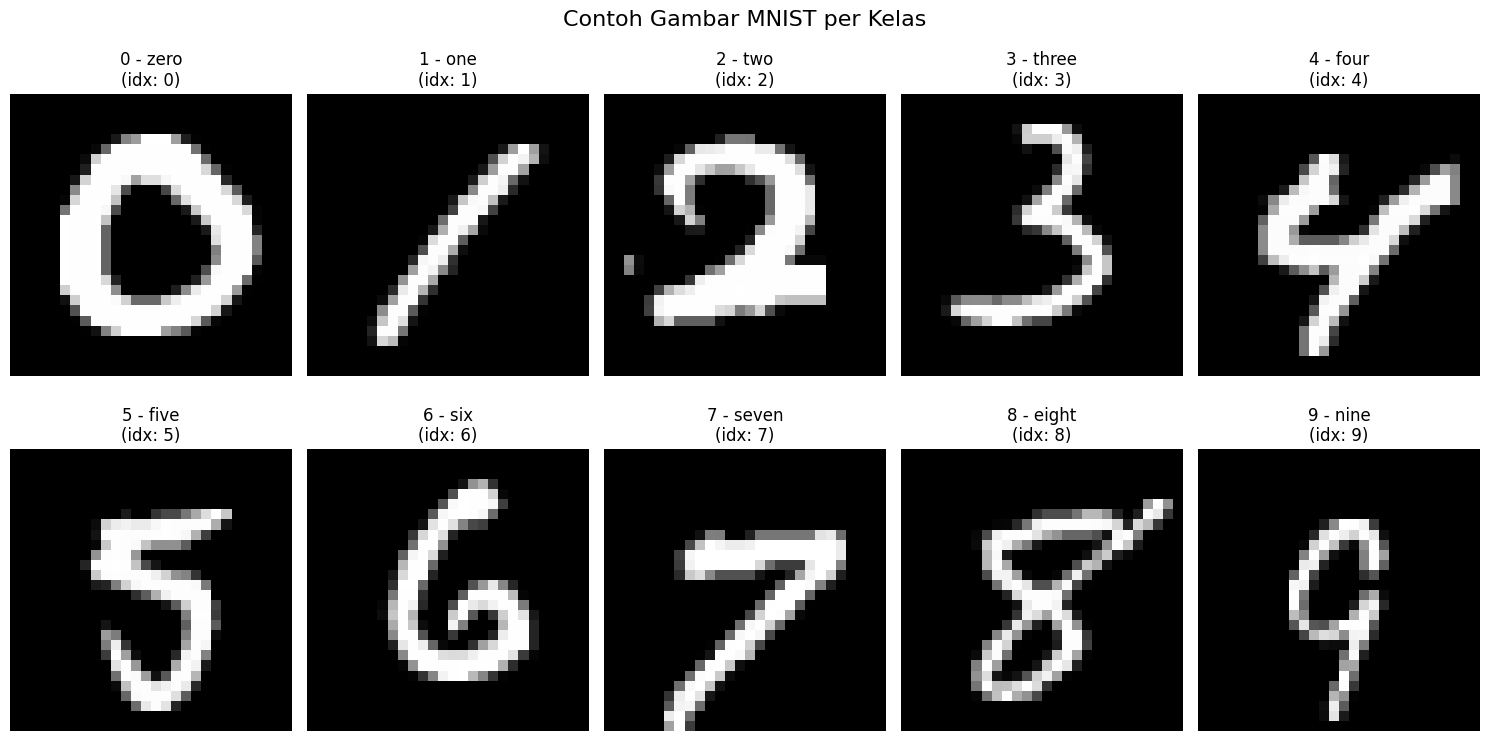

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
fig.suptitle('Contoh Gambar MNIST per Kelas', fontsize=16)

for idx, class_name in enumerate(class_names):
    # Ambil satu gambar pertama dari setiap kelas
    class_indices = np.where(labels == idx)[0]
    sample_idx = class_indices[0]

    row = idx // 5
    col = idx % 5

    # Tampilkan gambar
    axes[row, col].imshow(images[sample_idx], cmap='gray')
    axes[row, col].set_title(f'{class_name}\n(idx: {idx})')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Brightness Distribution

    Kelas      Mean       Std  Min  Max
 0 - zero 44.196658 88.659032    0  255
  1 - one 19.353440 62.262110    0  255
  2 - two 37.861897 82.978976    0  255
3 - three 36.156647 81.136664    0  255
 4 - four 30.926470 75.832832    0  255
 5 - five 32.845634 77.432034    0  255
  6 - six 35.036416 80.322041    0  255
7 - seven 29.230081 74.412456    0  255
8 - eight 38.289738 82.938621    0  255
 9 - nine 31.314598 76.218824    0  255


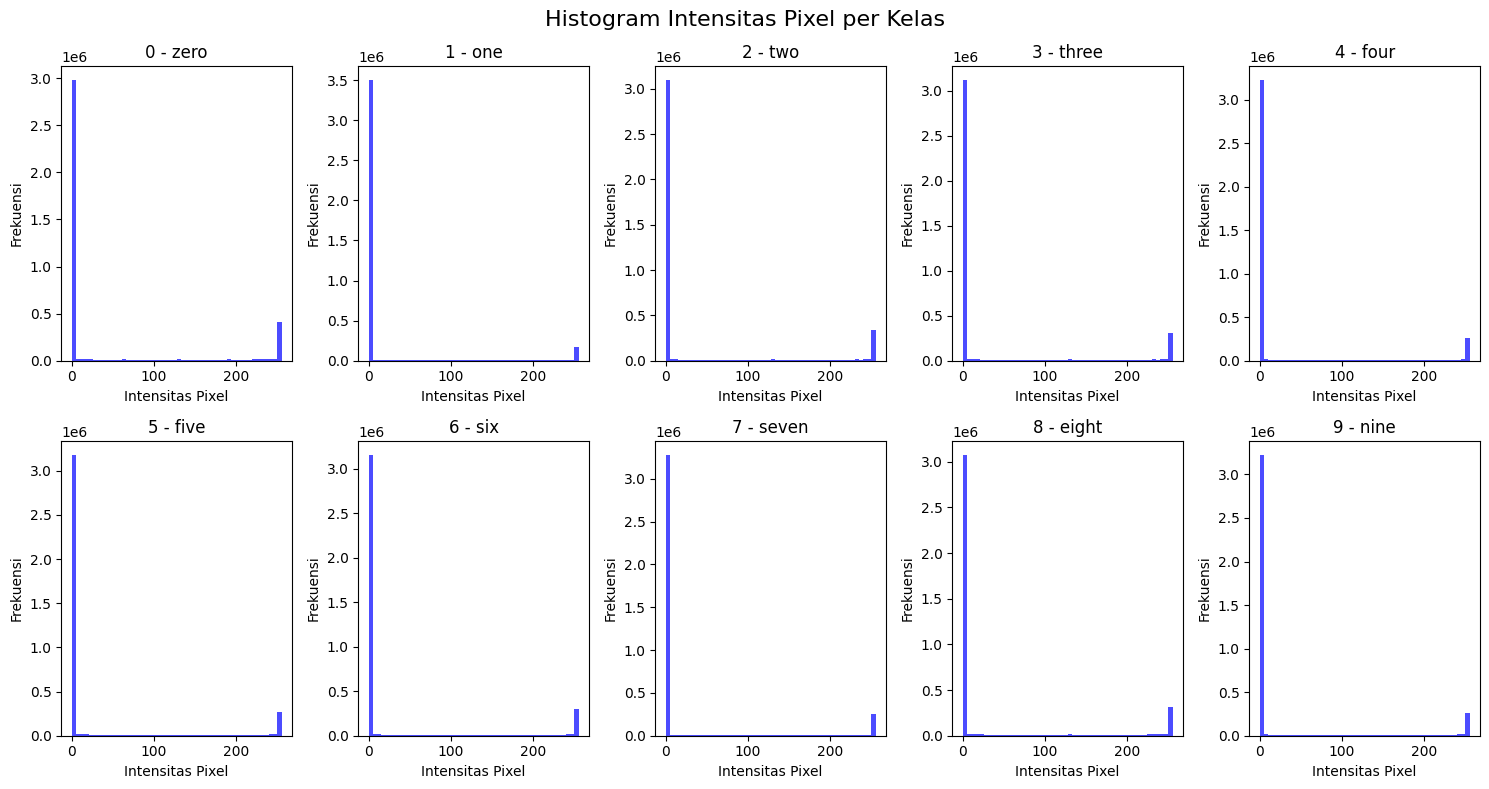

In [10]:
# Statistik ringkasan per kelas
pixel_stats = []
for i in range(10):
    class_images = images[labels == i]
    pixel_stats.append({
        'Kelas': class_names[i],
        'Mean': class_images.mean(),
        'Std': class_images.std(),
        'Min': class_images.min(),
        'Max': class_images.max()
    })

pixel_df = pd.DataFrame(pixel_stats)
print(pixel_df.to_string(index=False))

# Visualisasi distribusi pixel per kelas
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
fig.suptitle('Histogram Intensitas Pixel per Kelas', fontsize=16)

for idx, class_name in enumerate(class_names):
    row = idx // 5
    col = idx % 5

    class_images = images[labels == idx]
    axes[row, col].hist(class_images.flatten(), bins=50, alpha=0.7, color='blue')
    axes[row, col].set_title(f'{class_name}')
    axes[row, col].set_xlabel('Intensitas Pixel')
    axes[row, col].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## Analisis Mean Intensitas Pixel

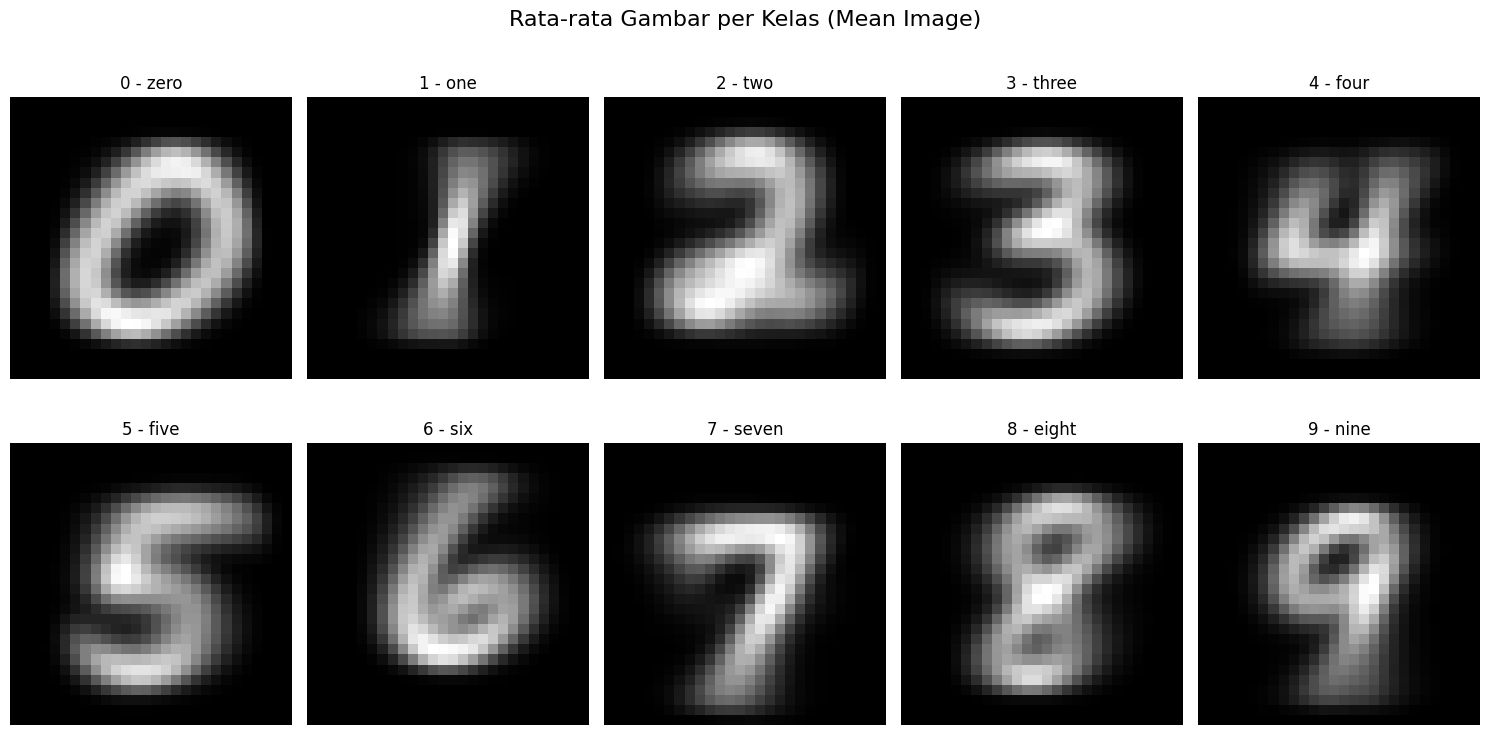


ANALISIS VARIANCE PIXEL
Variance global semua gambar: 0.0954
0 - zero       : 0.1209
1 - one        : 0.0596
2 - two        : 0.1059
3 - three      : 0.1012
4 - four       : 0.0884
5 - five       : 0.0922
6 - six        : 0.0992
7 - seven      : 0.0852
8 - eight      : 0.1058
9 - nine       : 0.0893


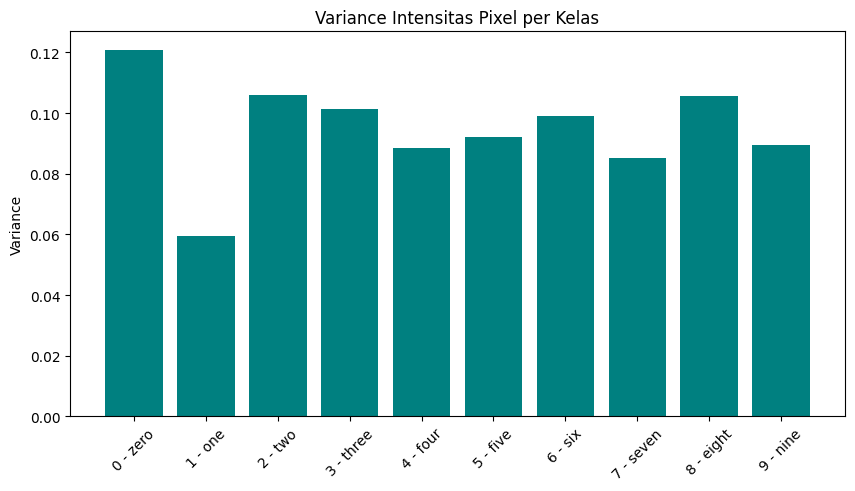

In [11]:
# Mean image per kelas
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
fig.suptitle('Rata-rata Gambar per Kelas (Mean Image)', fontsize=16)

for idx, class_name in enumerate(class_names):
    row = idx // 5
    col = idx % 5

    class_images = images[labels == idx]
    mean_img = class_images.mean(axis=0)

    axes[row, col].imshow(mean_img, cmap='gray')
    axes[row, col].set_title(f'{class_name}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Analisis variance per pixel (penting untuk normalisasi)
print("\n"+"ANALISIS VARIANCE PIXEL")
print("="*50)

# Hitung variance global
global_variance = np.var(images / 255.0)
print(f"Variance global semua gambar: {global_variance:.4f}")

# Variance per kelas
variance_per_class = []
for i in range(10):
    class_images = images[labels == i] / 255.0
    var = np.var(class_images)
    variance_per_class.append(var)
    print(f"{class_names[i]:15s}: {var:.4f}")

# Visualisasi variance per kelas
plt.figure(figsize=(10, 5))
plt.bar(class_names, variance_per_class, color='teal')
plt.title('Variance Intensitas Pixel per Kelas')
plt.ylabel('Variance')
plt.xticks(rotation=45)
plt.show()

# **DEFINISI FUNGSI MODULAR**

---



## Setup MNIST

In [20]:
def setup_mnist_environment(model_name, force_remount=True):
    """
    Menangani mounting drive, setup path, dan inisialisasi DataLoaders.
    """
    from google.colab import drive
    import os
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader

    # 1. Mount Drive (hanya jika belum di-mount)
    drive.mount('/content/drive', force_remount=True)

    # 2. Setup Paths
    model_dir = '/content/drive/MyDrive/model_modular'
    os.makedirs(model_dir, exist_ok=True)
    path = os.path.join(model_dir, model_name)

    train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

    return path, train_loader, test_loader

print("✅ Helper function setup_mnist_environment siap digunakan.")

✅ Helper function setup_mnist_environment siap digunakan.


## Load or Training Model & Eval Model

In [21]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def load_and_prepare_model(model_class, model_path, train_loader, test_loader, device, num_epochs=10, lr=0.001):
    model = model_class().to(device)
    history = {'loss': [], 'accuracy': []}

    if os.path.exists(model_path):
        print(f"✅ Loading existing model from {model_path}...")
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', history)
        print(f"✅ Model loaded. Previous accuracy: {history['accuracy'][-1]:.2f}%" if history['accuracy'] else "✅ Model loaded.")
    else:
        print(f"❌ No model found at {model_path}. Starting training...")
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # 🔥 Track best model
        best_acc = 0.0
        best_model_state = None
        best_epoch = 0

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            acc = evaluate_accuracy(model, test_loader, device)
            avg_loss = running_loss / len(train_loader)
            history['loss'].append(avg_loss)
            history['accuracy'].append(acc)
            print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {acc:.2f}%")

            # 🔥 Simpan bobot jika akurasi terbaik
            if acc > best_acc:
                best_acc = acc
                best_epoch = epoch + 1
                best_model_state = copy.deepcopy(model.state_dict())
                print(f"   🏆 Best model updated (epoch {best_epoch}, acc {best_acc:.2f}%)")

        # 🔥 Load kembali bobot terbaik sebelum disimpan
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
            print(f"\n✅ Restored best model from epoch {best_epoch} (acc {best_acc:.2f}%)")

        print(f"💾 Saving model to {model_path}...")
        torch.save({'model_state_dict': model.state_dict(), 'history': history}, model_path)
        print("✅ Training complete and model saved.")

    return model, history

print("✅ Unified Model Manager & Trainer defined!")

def get_best_accuracy(history, metric='accuracy'):

    if not history.get('accuracy'):
        print("⚠️ History kosong, tidak ada data akurasi.")
        return {
            'best_accuracy': 0.0,
            'best_epoch': 0,
            'best_loss': 0.0,
            'all_accuracies': [],
            'final_accuracy': 0.0
        }

    accuracies = history['accuracy']
    losses = history.get('loss', [])

    if metric == 'accuracy':
        best_value = max(accuracies)
        best_epoch = accuracies.index(best_value) + 1  # 1-indexed
    else:  # 'loss'
        best_value = min(losses) if losses else 0.0
        best_epoch = losses.index(best_value) + 1 if losses else 0

    result = {
        'best_accuracy': max(accuracies),
        'best_epoch': accuracies.index(max(accuracies)) + 1,
        'best_loss': min(losses) if losses else 0.0,
        'all_accuracies': accuracies,
        'final_accuracy': accuracies[-1]
    }

    print(f"📊 Best Accuracy : {result['best_accuracy']:.2f}% (Epoch {result['best_epoch']})")
    print(f"📊 Final Accuracy: {result['final_accuracy']:.2f}% (Epoch {len(accuracies)})")
    print(f"📊 Best Loss     : {result['best_loss']:.4f}")

    return result

✅ Unified Model Manager & Trainer defined!


## Fungsi Kuantisasi Modular

Standard & Fine-Grained Quantization Ternary


In [22]:
import torch
import torch.nn as nn
import copy
import numpy as np
import os
import json

def standard_ternary_quantize(weight_tensor, asymmetric=False):
    """
    Standard ternary quantization dengan alpha yang akurat.
    """
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()

    if not asymmetric:
        abs_weights = torch.abs(flat_weights)
        if abs_weights.max().item() == 0:
            return torch.zeros_like(weight_tensor), 0.0

        # 🔥 Hitung threshold
        delta = 0.7 * torch.mean(abs_weights)
        mask = abs_weights > delta

        if mask.sum() == 0:
            return torch.zeros_like(weight_tensor), 0.0

        # 🔥 Buat bobot ternary
        ternary_flat = torch.zeros_like(flat_weights)
        ternary_flat[flat_weights > delta] = 1.0   # sementara +1
        ternary_flat[flat_weights < -delta] = -1.0 # sementara -1

        # 🔥 Hitung alpha dari bobot yang sudah ternarized
        # Ambil nilai absolut dari bobot yang bukan nol
        nonzero_mask = ternary_flat != 0
        if nonzero_mask.sum() > 0:
            # Alpha adalah rata-rata dari |bobot asli| yang lolos threshold
            alpha = abs_weights[mask].mean()
        else:
            alpha = 0.0

        # 🔥 Terapkan alpha
        ternary_flat *= alpha

        # 🔥 VERIFIKASI: Pastikan alpha yang dikembalikan sama dengan yang digunakan
        return ternary_flat.reshape(original_shape), alpha.item()
    else:
        # Asymmetric version
        pos_mask = flat_weights > 0
        neg_mask = flat_weights < 0
        a_pos, a_neg = 0.0, 0.0
        d_pos, d_neg = 0.0, 0.0

        if pos_mask.any():
            pos_vals = flat_weights[pos_mask]
            d_pos = 0.7 * torch.mean(pos_vals)
            m_pos = pos_vals > d_pos
            if m_pos.any():
                a_pos = pos_vals[m_pos].mean()

        if neg_mask.any():
            neg_vals = flat_weights[neg_mask]
            d_neg = 0.7 * torch.mean(torch.abs(neg_vals))
            m_neg = torch.abs(neg_vals) > d_neg
            if m_neg.any():
                a_neg = neg_vals[m_neg].mean()

        ternary_flat = torch.zeros_like(flat_weights)
        ternary_flat[flat_weights > d_pos] = a_pos
        ternary_flat[flat_weights < -d_neg] = a_neg

        avg_alpha = (abs(a_pos) + abs(a_neg)) / 2.0
        return ternary_flat.reshape(original_shape), avg_alpha.item()

def apply_standard_ternary_to_model(model, asymmetric=False, verbose=False,
                                   save_path=None, skip_conv1=False):
    """
    Apply standard ternary quantization to model.
    """
    if save_path and os.path.exists(save_path):
        print(f"✅ Loading existing Standard Ternary model from {save_path}...")
        return load_ternary_safetensors(save_path, model), None

    model_q = copy.deepcopy(model)
    layer_alphas = []

    # 🔥 Deteksi ResNet
    is_resnet = hasattr(model_q, 'model') and hasattr(model_q.model, 'conv1')

    for name, module in model_q.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            # 🔥 HANYA skip conv1, BUKAN semua layer!
            should_skip = False
            if skip_conv1:
                # Hanya skip jika nama layer adalah 'model.conv1' atau 'conv1'
                if name == 'model.conv1' or name == 'conv1':
                    should_skip = True

            if should_skip:
                if verbose:
                    print(f"  ⏭️ {name}: skipped (kept FP32)")
                continue

            # 🔥 Kuantisasi layer lainnya
            ternary_weight, alpha = standard_ternary_quantize(
                module.weight.data,
                asymmetric=asymmetric
            )
            module.weight.data = ternary_weight

            # 🔥 Gunakan alpha dari bobot AKTUAL
            actual_alpha = get_alpha_from_weight(module.weight.data)
            layer_alphas.append(actual_alpha)

            if verbose:
                print(f"  ✓ {name}: quantized with alpha={actual_alpha:.4f}")

    if save_path:
        save_ternary_safetensors(model_q, alphas=layer_alphas, path=save_path)
    return model_q, layer_alphas

def get_alpha_from_weight(weight_tensor):
    """
    Ekstrak alpha dari bobot ternary yang sudah jadi.
    Alpha adalah nilai absolut terbesar dari bobot non-zero.
    """
    w = weight_tensor.flatten()
    # Ambil nilai unik (dengan toleransi pembulatan)
    unique_vals = torch.unique(w.round(decimals=6))
    # Ambil nilai positif (alpha)
    pos_vals = unique_vals[unique_vals > 0]
    if len(pos_vals) > 0:
        return pos_vals.max().item()
    return 0.0

def ternary_quantize_group(weight_tensor, group_size=4, asymmetric=False):
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    n = flat_weights.numel()
    ternary_flat = torch.zeros_like(flat_weights)
    alphas = []
    for i in range(0, n, group_size):
        group = flat_weights[i:min(i+group_size, n)]
        if len(group) == 0: continue
        if not asymmetric:
            abs_group = torch.abs(group)
            if abs_group.max().item() == 0:
                alphas.append(0.0)
                continue
            thresholds = torch.linspace(abs_group.min().item(), abs_group.max().item(), steps=20)
            best_delta, best_score = 0, -float('inf')
            for delta in thresholds:
                mask = abs_group > delta
                if mask.sum() == 0: continue
                score = (abs_group[mask].sum() ** 2) / mask.sum().float()
                if score > best_score: best_score, best_delta = score, delta
            mask = abs_group > best_delta
            if mask.sum() == 0:
                alphas.append(0.0)
                continue
            alpha = abs_group[mask].sum() / mask.sum().float()
            alphas.append(alpha.item())
            ternary_group = torch.zeros_like(group)
            ternary_group[group > best_delta] = alpha
            ternary_group[group < -best_delta] = -alpha
        else:
            pos_mask = group > 0
            neg_mask = group < 0
            a_pos, a_neg = 0.0, 0.0
            d_pos, d_neg = 0.0, 0.0
            if pos_mask.any():
                pos_vals = group[pos_mask]
                d_pos = 0.7 * torch.mean(pos_vals)
                m_pos = pos_vals > d_pos
                if m_pos.any(): a_pos = torch.mean(pos_vals[m_pos])
            if neg_mask.any():
                neg_vals = group[neg_mask]
                d_neg = 0.7 * torch.mean(torch.abs(neg_vals))
                m_neg = torch.abs(neg_vals) > d_neg
                if m_neg.any(): a_neg = torch.mean(neg_vals[m_neg])
            ternary_group = torch.zeros_like(group)
            ternary_group[group > d_pos] = a_pos
            ternary_group[group < -d_neg] = a_neg
            alphas.append((abs(a_pos) + abs(a_neg)).item() / 2.0 if torch.is_tensor(a_pos) else (abs(a_pos) + abs(a_neg)) / 2.0)
        ternary_flat[i:min(i+group_size, n)] = ternary_group
    return ternary_flat.reshape(original_shape), alphas

def apply_fgq_to_model(model, group_size=4, asymmetric=False, verbose=False, save_path=None):
    if isinstance(group_size, (list, set, tuple)):
        results = {}
        for gs in sorted(list(group_size)):
            sub_save_path = save_path.replace('.safetensors', f'_gs{gs}.safetensors') if save_path else None
            if sub_save_path and os.path.exists(sub_save_path):
                if verbose: print(f"✅ Loading existing FGQ model (GS={gs}) from {sub_save_path}...")
                m_q = load_ternary_safetensors(sub_save_path, model)
                results[gs] = (m_q, None)
            else:
                if verbose: print(f"\n--- Processing Group Size: {gs} (Asymmetric={asymmetric}) ---")
                m_q, a_m = apply_fgq_to_model(model, gs, asymmetric, verbose, sub_save_path)
                results[gs] = (m_q, a_m)
        return results

    if save_path and os.path.exists(save_path):
        print(f"✅ Loading existing FGQ model (GS={group_size}) from {save_path}...")
        return load_ternary_safetensors(save_path, model), None

    model_q = copy.deepcopy(model)
    all_alpha_means = []
    for name, module in model_q.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            ternary_weight, alphas = ternary_quantize_group(module.weight.data, group_size, asymmetric)
            module.weight.data = ternary_weight
            m_alpha = np.mean(alphas) if alphas else 0
            all_alpha_means.append(m_alpha)
            if verbose: print(f"  ✓ {name}: FGQ N={group_size}, Asym={asymmetric}, mean_alpha={m_alpha:.4f}")

    if save_path:
        save_ternary_safetensors(model_q, group_size=group_size, path=save_path)
    return model_q, all_alpha_means

def find_best_fgq_model(fgq_results, test_loader, device, save_log_path=None):
    best_acc = -1.0
    best_gs = None
    best_model = None
    accuracy_log = {}

    print("\n--- Evaluating All Group Sizes ---")
    for gs, (model_q, _) in fgq_results.items():
        acc = evaluate_accuracy(model_q, test_loader, device)
        accuracy_log[int(gs)] = float(acc)
        print(f"Group Size {gs}: Accuracy = {acc:.2f}%")
        if acc > best_acc:
            best_acc = acc
            best_gs = gs
            best_model = model_q

    print(f"\n✅ Best Result: Group Size {best_gs} with Accuracy {best_acc:.2f}%")

    if save_log_path:
        with open(save_log_path, 'w') as f:
            json.dump({"model_info": "FGQ Results", "accuracies": accuracy_log, "best_gs": int(best_gs)}, f, indent=4)
        print(f"💾 Accuracy log saved to: {save_log_path}")

    return best_gs, best_model, best_acc

## Definisi Model

### LeNet-5

In [23]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Redefine Model Class
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 2. Re-initialize DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Standard normalization for MNIST
])

test_dataset = datasets.MNIST(root='./data_mnist', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 3. Instantiate model and define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)

print("✅ Setup for verification complete: Model and Test Loader are ready.")

✅ Setup for verification complete: Model and Test Loader are ready.


### ResNet-18

In [24]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Redefine Model Class for ResNet18
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        # Load a pre-trained ResNet18 model
        self.model = models.resnet18(weights=None) # weights=None to avoid downloading ImageNet weights for now

        # Modify the first convolution layer for single-channel input (MNIST images are grayscale)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Modify the final fully connected layer to match the number of classes (MNIST has 10 classes)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

# Instantiate model and define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet18().to(device)

print("✅ ResNet18 model defined and ready for MNIST.")

✅ ResNet18 model defined and ready for MNIST.


## Fungsi Penyimpanan Kuantisasi

In [25]:
import torch
import os
import copy
import json
from safetensors.torch import save_file, load_file
from safetensors import safe_open

def pack_2bit(mask):
    """
    Pack 4 ternary values into 1 byte (using 0, 1, 2 mapping)
    """
    if mask.device.type == 'cuda':
        mask = mask.cpu()

    # 🔥 Pastikan mask hanya berisi 0, 1, 2
    mask = mask.clamp(0, 2)

    flat = mask.flatten().to(torch.uint8)
    n = flat.numel()
    pad = (4 - (n % 4)) % 4
    if pad > 0:
        flat = torch.cat([flat, torch.zeros(pad, dtype=torch.uint8)])

    # Reshape ke (N/4, 4)
    grouped = flat.view(-1, 4)

    # 🔥 Pack dengan bit operation yang aman
    packed = torch.zeros(grouped.size(0), dtype=torch.uint8)
    for i in range(4):
        # Pastikan nilai 0-3, lalu shift
        packed |= (grouped[:, i] & 3) << (2 * i)

    return packed, mask.shape

def unpack_2bit(packed, shape, numel):
    """
    Unpack uint8 back to ternary mask
    """
    if packed.device.type == 'cuda':
        packed = packed.cpu()

    n = packed.numel()
    # Unpack: 1 byte menjadi 4 nilai 2-bit
    unpacked = torch.zeros(n, 4, dtype=torch.uint8)
    for i in range(4):
        unpacked[:, i] = (packed >> (2 * i)) & 3

    # 🔥 Flatten dan ambil sesuai numel
    mask = unpacked.flatten()[:numel].reshape(shape)
    return mask.to(torch.int8)

def get_alpha_from_weight(weight_tensor):
    """
    [Dipertahankan untuk kompatibilitas / debugging]
    Ekstrak SATU alpha global dari bobot ternary (nilai absolut terbesar).
    ⚠️ JANGAN dipakai untuk save/load FGQ atau asymmetric — gunakan
    get_group_alphas_from_weight, karena satu layer bisa punya banyak alpha berbeda.
    """
    w = weight_tensor.flatten()
    unique_vals = torch.unique(w.round(decimals=6))
    pos_vals = unique_vals[unique_vals > 0]
    if len(pos_vals) > 0:
        return pos_vals.max().item()
    return 0.0

# ============================================================
# 🔧 FIX: ekstraksi alpha PER GRUP (bukan satu alpha global per layer)
# ============================================================
def get_group_alphas_from_weight(w_flat, group_size):
    """
    Untuk tiap grup sepanjang `group_size` elemen (berurutan sesuai flatten),
    ekstrak alpha positif & alpha negatif dari bobot yang SUDAH dikuantisasi.

    - Bekerja untuk symmetric (alpha_pos == alpha_neg per grup) maupun
      asymmetric (alpha_pos != alpha_neg per grup) secara otomatis, karena
      nilainya diambil langsung dari bobot ternary hasil kuantisasi.
    - Bekerja juga untuk "standard ternary" (bukan FGQ) dengan cara
      memanggil fungsi ini dengan group_size = numel (artinya: 1 grup
      mencakup seluruh layer) — jadi satu fungsi ini menggantikan
      get_alpha_from_weight() di semua kasus save/load.

    Return: (alpha_pos, alpha_neg) — masing-masing tensor 1D sepanjang
    jumlah grup (n_groups).
    """
    n = w_flat.numel()
    n_groups = (n + group_size - 1) // group_size
    alpha_pos = torch.zeros(n_groups, dtype=torch.float32)
    alpha_neg = torch.zeros(n_groups, dtype=torch.float32)
    for gi in range(n_groups):
        start = gi * group_size
        end = min(start + group_size, n)
        chunk = w_flat[start:end]
        pos = chunk[chunk > 0]
        neg = chunk[chunk < 0]
        if pos.numel() > 0:
            alpha_pos[gi] = pos.max()
        if neg.numel() > 0:
            alpha_neg[gi] = neg.abs().max()
    return alpha_pos, alpha_neg


def save_ternary_safetensors(model, alphas=None, group_size=None, path='model.safetensors',
                            skip_layers=None):
    """
    alphas   : sudah tidak dipakai untuk perhitungan (dipertahankan hanya demi
               kompatibilitas signature dengan kode lama) — alpha SELALU
               diekstrak ulang langsung dari bobot ter-kuantisasi, PER GRUP.
    group_size: ukuran grup FGQ (4/8/16, dst). None berarti "standard ternary"
               → 1 grup mencakup seluruh layer (perilaku lama, tapi kini benar
               untuk asymmetric juga karena alpha_pos & alpha_neg disimpan
               terpisah, bukan digabung/di-max-kan).
    """
    if skip_layers is None:
        skip_layers = []

    model = model.cpu()
    tensors = {}
    meta_list = []
    total_layers = 0
    saved_layers = 0

    print("\n📝 Proses Save Model ke Safetensors (FIXED: per-group alpha)")
    print("="*60)

    for name, module in model.named_modules():
        if name in skip_layers:
            print(f"  ⏭️ SKIP (FP32): {name}")
            continue

        # --- BatchNorm ---
        if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            total_layers += 1
            tensors[f"{name}.weight"] = module.weight.data.clone()
            tensors[f"{name}.bias"] = module.bias.data.clone()
            tensors[f"{name}.running_mean"] = module.running_mean.clone()
            tensors[f"{name}.running_var"] = module.running_var.clone()
            meta_list.append({"n": name, "type": "bn"})
            saved_layers += 1
            print(f"  ✅ BN: {name}")
            continue

        # --- Conv2d / Linear ---
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            total_layers += 1
            w = module.weight.data
            w_flat = w.flatten()
            gs = group_size if group_size else w_flat.numel()  # standard ternary -> 1 grup (whole layer)

            print(f"  🔄 Processing: {name}")
            print(f"     - Shape: {w.shape}  | group_size dipakai: {gs}")

            # 🔥 FIX: alpha per grup (pos & neg terpisah), bukan satu alpha global
            alpha_pos, alpha_neg = get_group_alphas_from_weight(w_flat, gs)
            tensors[f"{name}.alpha_pos"] = alpha_pos.to(torch.float16)
            tensors[f"{name}.alpha_neg"] = alpha_neg.to(torch.float16)
            print(f"     - Jumlah grup alpha: {len(alpha_pos)} "
                  f"(distinct pos={len(torch.unique(alpha_pos[alpha_pos>0]))}, "
                  f"distinct neg={len(torch.unique(alpha_neg[alpha_neg>0]))})")

            # Buat mask ternary untuk packing
            m = torch.zeros_like(w, dtype=torch.int8)
            m[w < 0] = 0
            m[w == 0] = 1
            m[w > 0] = 2

            packed, original_shape = pack_2bit(m)
            tensors[f"{name}.p"] = packed

            info = {
                "n": name,
                "type": "linear",
                "s": list(original_shape),
                "num": w.numel(),
                "group_size": gs,
                "has_bias": module.bias is not None,
            }

            if module.bias is not None:
                tensors[f"{name}.bias"] = module.bias.data.clone()

            meta_list.append(info)
            saved_layers += 1
            print(f"     ✅ Saved to metadata")

    print("="*60)
    print(f"📊 Total layer ditemukan: {total_layers}")
    print(f"📊 Layer disimpan: {saved_layers}")
    print(f"📊 Layer di-skip: {len(skip_layers)}")

    if saved_layers == 0:
        print("❌ ERROR: Tidak ada layer yang disimpan!")
        return meta_list

    save_file(tensors, path, metadata={"config": json.dumps(meta_list)})

    file_size = os.path.getsize(path) / 1024
    print(f"✅ Saved: {path} ({file_size:.1f} KB, {len(meta_list)} layers)")

    return meta_list

def load_ternary_safetensors(path, template_model, verbose=True):
    from safetensors import safe_open

    tensors = load_file(path)

    if verbose:
        print("\n🔍 Debug Load (FIXED: per-group alpha):")
        print("="*60)

    with safe_open(path, framework="pt") as f:
        metadata = f.metadata()
        config_str = metadata["config"]
        meta_list = json.loads(config_str)
        if verbose:
            print(f"✅ Berhasil parse JSON: {len(meta_list)} layers")

    model = copy.deepcopy(template_model)
    state_dict = model.state_dict()
    loaded_keys = set()

    for info in meta_list:
        name = info["n"]

        if info.get("type") == "bn":
            for suffix in ['.weight', '.bias', '.running_mean', '.running_var']:
                key = f"{name}{suffix}"
                if key in state_dict:
                    state_dict[key] = tensors[f"{name}{suffix}"]
                    loaded_keys.add(key)
            continue

        if info.get("type") == "linear":
            weight_key = f"{name}.weight"

            packed = tensors[f"{name}.p"]
            mask = unpack_2bit(packed, info["s"], info["num"])
            mask_flat = mask.flatten()

            n = info["num"]
            gs = info.get("group_size", n)  # fallback: file lama = 1 grup (whole layer)

            if f"{name}.alpha_pos" in tensors and f"{name}.alpha_neg" in tensors:
                # 🔥 FIX: broadcast alpha PER GRUP ke tiap elemen sesuai grupnya
                alpha_pos = tensors[f"{name}.alpha_pos"]
                alpha_neg = tensors[f"{name}.alpha_neg"]
                n_groups = alpha_pos.numel()
                group_idx = (torch.arange(n) // gs).clamp(max=n_groups - 1)
                ap = alpha_pos[group_idx]
                an = alpha_neg[group_idx]

                w_rec = torch.zeros(n, dtype=torch.float16)
                w_rec[mask_flat == 2] = ap[mask_flat == 2]
                w_rec[mask_flat == 0] = -an[mask_flat == 0]

                if verbose:
                    print(f"  📊 {name}: {n_groups} grup alpha (group_size={gs}) berhasil di-broadcast")
            elif f"{name}.alpha" in tensors:
                # Kompatibilitas mundur: file lama format single-alpha (buggy)
                alpha = tensors[f"{name}.alpha"].item()
                w_rec = torch.zeros(n, dtype=torch.float16)
                w_rec[mask_flat == 2] = alpha
                w_rec[mask_flat == 0] = -alpha
                if verbose:
                    print(f"  ⚠️ {name}: file lama (format single-alpha), akurasi mungkin masih mismatch")
            else:
                w_rec = torch.zeros(n, dtype=torch.float16)

            # Verifikasi perbedaan
            if verbose and weight_key in state_dict:
                orig_w = state_dict[weight_key].flatten().cpu()
                rec_w = w_rec.flatten().cpu()
                max_diff = (orig_w - rec_w).abs().max().item()
                if max_diff > 1e-2:
                    print(f"     ⚠️ PERBEDAAN DETEKSI! max_diff={max_diff:.6f}")
                    print(f"        Orig mean: {orig_w.mean().item():.6f}, Rec mean: {rec_w.mean().item():.6f}")
                else:
                    print(f"     ✅ Cocok (max_diff={max_diff:.6f})")

            state_dict[weight_key] = w_rec.reshape(info["s"])
            loaded_keys.add(weight_key)

            if info.get("has_bias", False) and f"{name}.bias" in tensors:
                state_dict[f"{name}.bias"] = tensors[f"{name}.bias"]
                loaded_keys.add(f"{name}.bias")

    model.load_state_dict(state_dict)
    return model


## Generate Input Batch

In [26]:
import torch
import numpy as np
from torchvision import datasets, transforms

# Load Fashion-MNIST test set
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Ambil 100 gambar pertama
batch_size = 100
inputs = []
for i in range(batch_size):
    img, label = test_dataset[i]
    input_flat = img.numpy().flatten().astype(np.float32)
    inputs.append(input_flat)

# Simpan sebagai satu file .bin (100 x 784 = 78,400 float32)
all_inputs = np.array(inputs).flatten()
all_inputs.tofile('batch_input.bin')
print(f"✅ Batch input saved: {all_inputs.shape}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 335kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.99MB/s]

✅ Batch input saved: (78400,)


# **PENGUJIAN TRAINING & KUANTISASI**

---



## Model Setup

#### ResNet-18

In [33]:
# 1. Siapkan environment (Drive, Path, Data)
# Perbaikan: Fungsi setup_mnist_environment sekarang mengecek status mount
model_path_resnet, train_loader_resnet, test_loader_resnet = setup_mnist_environment('resnet18_mnist_baseline.pth')

# 2. Panggil manager model
model_fp32_resnet, history_resnet = load_and_prepare_model(
    ResNet18,
    model_path_resnet,
    train_loader_resnet,
    test_loader_resnet,
    device,
    num_epochs=5
)

best_info_resnet = get_best_accuracy(history_resnet)
print(f"Baseline terbaik: {best_info_resnet['best_accuracy']:.2f}% (epoch {best_info_resnet['best_epoch']})")

Mounted at /content/drive
✅ Loading existing model from /content/drive/MyDrive/model_modular/resnet18_mnist_baseline.pth...
✅ Model loaded. Previous accuracy: 98.82%
📊 Best Accuracy : 98.82% (Epoch 5)
📊 Final Accuracy: 98.82% (Epoch 5)
📊 Best Loss     : 0.0289
Baseline terbaik: 98.82% (epoch 5)


#### LeNet-5

In [34]:
# 1. Siapkan environment (Drive, Path, Data)
model_path_lenet, train_loader_lenet, test_loader_lenet = setup_mnist_environment('lenet5_mnist_baseline.pth')

# 2. Panggil manager model
model_fp32_lenet, history_lenet = load_and_prepare_model(
    LeNet5,
    model_path_lenet,
    train_loader_lenet,
    test_loader_lenet,
    device,
    num_epochs=5
)

best_info_lenet = get_best_accuracy(history_lenet)
print(f"Baseline terbaik: {best_info_lenet['best_accuracy']:.2f}% (epoch {best_info_lenet['best_epoch']})")

Mounted at /content/drive
✅ Loading existing model from /content/drive/MyDrive/model_modular/lenet5_mnist_baseline.pth...
✅ Model loaded. Previous accuracy: 98.89%
📊 Best Accuracy : 98.89% (Epoch 5)
📊 Final Accuracy: 98.89% (Epoch 5)
📊 Best Loss     : 0.0393
Baseline terbaik: 98.89% (epoch 5)


## Kuantisasi Model

### *Standard Ternary Quantization*

#### ResNet-18

##### Symmetric threshold

In [35]:
model_ternary_resnet, alphas_resnet = apply_standard_ternary_to_model(model_fp32_resnet, asymmetric=False, verbose=True, skip_conv1=False, save_path="/content/drive/MyDrive/model_modular/safetensors_models/resnet18_standard_mnist_v1_stratified_symmetric.safetensors")
acc_ternary_resnet = evaluate_accuracy(model_ternary_resnet, test_loader, device)

print(f"Baseline: {best_info_resnet['best_accuracy']:.2f}%")
print(f"Ternary: {acc_ternary_resnet:.2f}%")

  ✓ model.conv1: quantized with alpha=0.1045
  ✓ model.layer1.0.conv1: quantized with alpha=0.0786
  ✓ model.layer1.0.conv2: quantized with alpha=0.0778
  ✓ model.layer1.1.conv1: quantized with alpha=0.0778
  ✓ model.layer1.1.conv2: quantized with alpha=0.0775
  ✓ model.layer2.0.conv1: quantized with alpha=0.0577
  ✓ model.layer2.0.conv2: quantized with alpha=0.0572
  ✓ model.layer2.0.downsample.0: quantized with alpha=0.1521
  ✓ model.layer2.1.conv1: quantized with alpha=0.0559
  ✓ model.layer2.1.conv2: quantized with alpha=0.0554
  ✓ model.layer3.0.conv1: quantized with alpha=0.0407
  ✓ model.layer3.0.conv2: quantized with alpha=0.0386
  ✓ model.layer3.0.downsample.0: quantized with alpha=0.1097
  ✓ model.layer3.1.conv1: quantized with alpha=0.0368
  ✓ model.layer3.1.conv2: quantized with alpha=0.0369
  ✓ model.layer4.0.conv1: quantized with alpha=0.0271
  ✓ model.layer4.0.conv2: quantized with alpha=0.0255
  ✓ model.layer4.0.downsample.0: quantized with alpha=0.0779
  ✓ model.layer4

In [36]:
import os

# Tentukan path lengkap ke file di Google Drive
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
model_filename = 'resnet18_standard_mnist_v1_stratified_symmetric.safetensors'
model_path = os.path.join(save_dir, model_filename)

# Load model menggunakan template ResNet18
if os.path.exists(model_path):
    model_loaded = load_ternary_safetensors(model_path, ResNet18())
    model_loaded.to(device)

    # Evaluasi sebelum dan sesudah
    model_ternary_resnet.eval()
    acc_before = evaluate_accuracy(model_ternary_resnet, test_loader, device)

    model_loaded.eval()
    acc_after = evaluate_accuracy(model_loaded, test_loader, device)

    print(f"Akurasi sebelum save: {acc_before:.2f}%")
    print(f"Akurasi setelah load: {acc_after:.2f}%")
    print(f"✅ Sama? {'Ya' if abs(acc_before - acc_after) < 0.01 else 'Tidak'}")

    # Verifikasi bobot conv1 tetap FP32
    if hasattr(model_loaded, 'model'):
        print(f"Conv1 mean: {model_loaded.model.conv1.weight.data.mean():.6f}")
        print(f"Conv1 std: {model_loaded.model.conv1.weight.data.std():.6f}")
else:
    print(f"❌ File tidak ditemukan: {model_path}")


🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 41 layers
  📊 model.conv1: 1 grup alpha (group_size=3136) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.247338
        Orig mean: -0.001267, Rec mean: -0.002501
  📊 model.layer1.0.conv1: 1 grup alpha (group_size=36864) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.318393
        Orig mean: -0.000009, Rec mean: -0.000961
  📊 model.layer1.0.conv2: 1 grup alpha (group_size=36864) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.338833
        Orig mean: 0.000187, Rec mean: -0.001619
  📊 model.layer1.1.conv1: 1 grup alpha (group_size=36864) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.307103
        Orig mean: -0.000262, Rec mean: -0.000723
  📊 model.layer1.1.conv2: 1 grup alpha (group_size=36864) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.323508
        Orig mean: -0.000032, Rec mean: -0.002405
  📊 model.layer2.0.conv1: 1 grup alpha (group_size=73728) berha

#### LeNet-5

##### Symmetric threshold

In [27]:
model_ternary_lenet, alphas_lenet = apply_standard_ternary_to_model(model_fp32_lenet, asymmetric=False, verbose=True,save_path="/content/drive/MyDrive/model_modular/safetensors_models/lenet5_standard_mnist_v1_stratified_symmetric.safetensors")
acc_ternary_lenet = evaluate_accuracy(model_ternary_lenet, test_loader, device)

print(f"Baseline: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_lenet:.2f}%")

  ✓ conv1: quantized with alpha=0.2316
  ✓ conv2: quantized with alpha=0.1280
  ✓ fc1: quantized with alpha=0.0676
  ✓ fc2: quantized with alpha=0.0841
  ✓ fc3: quantized with alpha=0.1122

📝 Proses Save Model ke Safetensors (FIXED: per-group alpha)
  🔄 Processing: conv1
     - Shape: torch.Size([6, 1, 5, 5])  | group_size dipakai: 150
     - Jumlah grup alpha: 1 (distinct pos=1, distinct neg=1)
     ✅ Saved to metadata
  🔄 Processing: conv2
     - Shape: torch.Size([16, 6, 5, 5])  | group_size dipakai: 2400
     - Jumlah grup alpha: 1 (distinct pos=1, distinct neg=1)
     ✅ Saved to metadata
  🔄 Processing: fc1
     - Shape: torch.Size([120, 400])  | group_size dipakai: 48000
     - Jumlah grup alpha: 1 (distinct pos=1, distinct neg=1)
     ✅ Saved to metadata
  🔄 Processing: fc2
     - Shape: torch.Size([84, 120])  | group_size dipakai: 10080
     - Jumlah grup alpha: 1 (distinct pos=1, distinct neg=1)
     ✅ Saved to metadata
  🔄 Processing: fc3
     - Shape: torch.Size([10, 84])  |

In [28]:
import os

# Tentukan path lengkap ke file di Google Drive
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
model_filename = 'lenet5_standard_mnist_v1_stratified_symmetric.safetensors'
model_path = os.path.join(save_dir, model_filename)

# Load model menggunakan template LeNet5
if os.path.exists(model_path):
    model_loaded = load_ternary_safetensors(model_path, LeNet5())
    model_loaded.to(device)

    # Evaluasi sebelum dan sesudah
    model_ternary_lenet.eval()
    acc_before = evaluate_accuracy(model_ternary_lenet, test_loader, device)

    model_loaded.eval()
    acc_after = evaluate_accuracy(model_loaded, test_loader, device)

    print(f"Akurasi sebelum save: {acc_before:.2f}%")
    print(f"Akurasi setelah load: {acc_after:.2f}%")
    print(f"✅ Sama? {'Ya' if abs(acc_before - acc_after) < 0.01 else 'Tidak'}")

    # Verifikasi bobot conv1 tetap FP32
    if hasattr(model_loaded, 'model'):
        print(f"Conv1 mean: {model_loaded.model.conv1.weight.data.mean():.6f}")
        print(f"Conv1 std: {model_loaded.model.conv1.weight.data.std():.6f}")
else:
    print(f"❌ File tidak ditemukan: {model_path}")


🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 5 layers
  📊 conv1: 1 grup alpha (group_size=150) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.430103
        Orig mean: 0.006043, Rec mean: 0.015434
  📊 conv2: 1 grup alpha (group_size=2400) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.209572
        Orig mean: 0.001211, Rec mean: -0.000854
  📊 fc1: 1 grup alpha (group_size=48000) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.117622
        Orig mean: -0.000149, Rec mean: 0.000546
  📊 fc2: 1 grup alpha (group_size=10080) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.175288
        Orig mean: -0.000115, Rec mean: 0.001760
  📊 fc3: 1 grup alpha (group_size=840) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.221271
        Orig mean: 0.000272, Rec mean: -0.005344
Akurasi sebelum save: 94.18%
Akurasi setelah load: 94.18%
✅ Sama? Ya


##### Aymmetric threshold

In [29]:
model_ternary_lenet, alphas_lenet = apply_standard_ternary_to_model(model_fp32_lenet, asymmetric=True, verbose=True,save_path="/content/drive/MyDrive/model_modular/safetensors_models/lenet5_standard_mnist_v1_stratified_asymmetric.safetensors")
acc_ternary_lenet = evaluate_accuracy(model_ternary_lenet, test_loader, device)

print(f"Baseline: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_lenet:.2f}%")

  ✓ conv1: quantized with alpha=0.2269
  ✓ conv2: quantized with alpha=0.1263
  ✓ fc1: quantized with alpha=0.0682
  ✓ fc2: quantized with alpha=0.0858
  ✓ fc3: quantized with alpha=0.1002

📝 Proses Save Model ke Safetensors (FIXED: per-group alpha)
  🔄 Processing: conv1
     - Shape: torch.Size([6, 1, 5, 5])  | group_size dipakai: 150
     - Jumlah grup alpha: 1 (distinct pos=1, distinct neg=1)
     ✅ Saved to metadata
  🔄 Processing: conv2
     - Shape: torch.Size([16, 6, 5, 5])  | group_size dipakai: 2400
     - Jumlah grup alpha: 1 (distinct pos=1, distinct neg=1)
     ✅ Saved to metadata
  🔄 Processing: fc1
     - Shape: torch.Size([120, 400])  | group_size dipakai: 48000
     - Jumlah grup alpha: 1 (distinct pos=1, distinct neg=1)
     ✅ Saved to metadata
  🔄 Processing: fc2
     - Shape: torch.Size([84, 120])  | group_size dipakai: 10080
     - Jumlah grup alpha: 1 (distinct pos=1, distinct neg=1)
     ✅ Saved to metadata
  🔄 Processing: fc3
     - Shape: torch.Size([10, 84])  |

In [30]:
import os

# Tentukan path lengkap ke file di Google Drive
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
model_filename = 'lenet5_standard_mnist_v1_stratified_asymmetric.safetensors'
model_path = os.path.join(save_dir, model_filename)

# Load model menggunakan template LeNet5
if os.path.exists(model_path):
    model_loaded = load_ternary_safetensors(model_path, LeNet5())
    model_loaded.to(device)

    # Evaluasi sebelum dan sesudah
    model_ternary_lenet.eval()
    acc_before = evaluate_accuracy(model_ternary_lenet, test_loader, device)

    model_loaded.eval()
    acc_after = evaluate_accuracy(model_loaded, test_loader, device)

    print(f"Akurasi sebelum save: {acc_before:.2f}%")
    print(f"Akurasi setelah load: {acc_after:.2f}%")
    print(f"✅ Sama? {'Ya' if abs(acc_before - acc_after) < 0.01 else 'Tidak'}")

    # Verifikasi bobot conv1 tetap FP32
    if hasattr(model_loaded, 'model'):
        print(f"Conv1 mean: {model_loaded.model.conv1.weight.data.mean():.6f}")
        print(f"Conv1 std: {model_loaded.model.conv1.weight.data.std():.6f}")
else:
    print(f"❌ File tidak ditemukan: {model_path}")


🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 5 layers
  📊 conv1: 1 grup alpha (group_size=150) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.443335
        Orig mean: -0.004665, Rec mean: 0.013763
  📊 conv2: 1 grup alpha (group_size=2400) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.211597
        Orig mean: -0.000983, Rec mean: -0.000439
  📊 fc1: 1 grup alpha (group_size=48000) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.118174
        Orig mean: 0.000014, Rec mean: 0.000672
  📊 fc2: 1 grup alpha (group_size=10080) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.177095
        Orig mean: -0.000069, Rec mean: 0.002388
  📊 fc3: 1 grup alpha (group_size=840) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.231862
        Orig mean: -0.000693, Rec mean: -0.008911
Akurasi sebelum save: 94.41%
Akurasi setelah load: 94.40%
✅ Sama? Ya


### *Fine-Grained Ternary Quantization*

#### ResNet-18

In [ ]:
fgq_results_resnet = apply_fgq_to_model(model_fp32_resnet, group_size={4, 8, 16}, asymmetric=True, verbose=True)

best_gs_resnet, best_model_fgq_resnet, best_acc_resnet = find_best_fgq_model(fgq_results_resnet, test_loader_resnet, device)

print(f"\nBaseline Accuracy: {history_resnet['accuracy'][-1]:.2f}%")
print(f"Akurasi Terbaik ditemukan pada Group Size {best_gs_resnet}: {best_acc_resnet:.2f}%")


--- Processing Group Size: 4 (Asymmetric=True) ---
  ✓ model.conv1: FGQ N=4, Asym=True, mean_́=0.0855
  ✓ model.layer1.0.conv1: FGQ N=4, Asym=True, mean_́=0.0628
  ✓ model.layer1.0.conv2: FGQ N=4, Asym=True, mean_́=0.0619
  ✓ model.layer1.1.conv1: FGQ N=4, Asym=True, mean_́=0.0621
  ✓ model.layer1.1.conv2: FGQ N=4, Asym=True, mean_́=0.0619
  ✓ model.layer2.0.conv1: FGQ N=4, Asym=True, mean_́=0.0458
  ✓ model.layer2.0.conv2: FGQ N=4, Asym=True, mean_́=0.0464
  ✓ model.layer2.0.downsample.0: FGQ N=4, Asym=True, mean_́=0.1237
  ✓ model.layer2.1.conv1: FGQ N=4, Asym=True, mean_́=0.0453
  ✓ model.layer2.1.conv2: FGQ N=4, Asym=True, mean_́=0.0448
  ✓ model.layer3.0.conv1: FGQ N=4, Asym=True, mean_́=0.0328
  ✓ model.layer3.0.conv2: FGQ N=4, Asym=True, mean_́=0.0314
  ✓ model.layer3.0.downsample.0: FGQ N=4, Asym=True, mean_́=0.0889
  ✓ model.layer3.1.conv1: FGQ N=4, Asym=True, mean_́=0.0300
  ✓ model.layer3.1.conv2: FGQ N=4, Asym=True, mean_́=0.0301
  ✓ model.layer4.0.conv1: FGQ N=4, Asym=Tru

#### LeNet-5

In [ ]:
fgq_results_lenet = apply_fgq_to_model(model_fp32_lenet, group_size={4, 8, 16}, asymmetric=True, verbose=True)

best_gs_lenet, best_model_fgq_lenet, best_acc_lenet = find_best_fgq_model(fgq_results_lenet, test_loader, device)

print(f"\nBaseline Accuracy: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Akurasi Terbaik ditemukan pada Group Size {best_gs_lenet}: {best_acc_lenet:.2f}%")


--- Processing Group Size: 4 (Asymmetric=True) ---
  ✓ conv1: FGQ N=4, Asym=True, mean_́=0.1777
  ✓ conv2: FGQ N=4, Asym=True, mean_́=0.0854
  ✓ fc1: FGQ N=4, Asym=True, mean_́=0.0496
  ✓ fc2: FGQ N=4, Asym=True, mean_́=0.0678
  ✓ fc3: FGQ N=4, Asym=True, mean_́=0.0906

--- Processing Group Size: 8 (Asymmetric=True) ---
  ✓ conv1: FGQ N=8, Asym=True, mean_́=0.1959
  ✓ conv2: FGQ N=8, Asym=True, mean_́=0.1003
  ✓ fc1: FGQ N=8, Asym=True, mean_́=0.0590
  ✓ fc2: FGQ N=8, Asym=True, mean_́=0.0791
  ✓ fc3: FGQ N=8, Asym=True, mean_́=0.1062

--- Processing Group Size: 16 (Asymmetric=True) ---
  ✓ conv1: FGQ N=16, Asym=True, mean_́=0.2127
  ✓ conv2: FGQ N=16, Asym=True, mean_́=0.1123
  ✓ fc1: FGQ N=16, Asym=True, mean_́=0.0637
  ✓ fc2: FGQ N=16, Asym=True, mean_́=0.0811
  ✓ fc3: FGQ N=16, Asym=True, mean_́=0.1095

--- Evaluating All Group Sizes ---
Group Size 4: Accuracy = 98.69%
Group Size 8: Accuracy = 98.43%
Group Size 16: Accuracy = 98.04%

✅ Best Result: Group Size 4 with Accuracy 98.69

## Perbandingan Akurasi

### ResNet18

In [ ]:
print(f"Baseline: {history_resnet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_resnet:.2f}%")
print(f"FGQ best Group Size: {best_acc_resnet:.2f}%")

### Lenet5

In [ ]:
print(f"Baseline: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_lenet:.2f}%")
print(f"FGQ best Group Size: {best_acc_lenet:.2f}%")

## Penyimpanan Model Kuantisasi

In [ ]:
import torch
import os
import copy
import json
from safetensors.torch import save_file, load_file

def pack_2bit(mask):
    """Pack 4 ternary values into 1 byte (using 0, 1, 2 mapping)"""
    flat = mask.flatten().to(torch.uint8)
    n = flat.numel()
    pad = (4 - (n % 4)) % 4
    if pad > 0:
        flat = torch.cat([flat, torch.zeros(pad, dtype=torch.uint8)])

    # Reshape to (N/4, 4) and pack
    grouped = flat.view(-1, 4)
    packed = (grouped[:, 0] & 3) | ((grouped[:, 1] & 3) << 2) | ((grouped[:, 2] & 3) << 4) | ((grouped[:, 3] & 3) << 6)
    return packed, mask.shape

def unpack_2bit(packed, shape, numel):
    """Unpack uint8 back to ternary mask"""
    unpacked = torch.zeros(packed.numel(), 4, dtype=torch.uint8, device=packed.device)
    unpacked[:, 0] = packed & 3
    unpacked[:, 1] = (packed >> 2) & 3
    unpacked[:, 2] = (packed >> 4) & 3
    unpacked[:, 3] = (packed >> 6) & 3

    mask = unpacked.flatten()[:numel].reshape(shape)
    return mask.to(torch.int8)

def save_ternary_safetensors(model, alphas=None, group_size=None, path='model.safetensors'):
    tensors = {}
    meta_list = []

    for name, module in model.named_modules():
        # --- BatchNorm ---
        if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            tensors[f"{name}.weight"] = module.weight.data.clone()
            tensors[f"{name}.bias"] = module.bias.data.clone()
            tensors[f"{name}.running_mean"] = module.running_mean.clone()
            tensors[f"{name}.running_var"] = module.running_var.clone()
            meta_list.append({"n": name, "type": "bn"})
            continue

        # --- Conv2d / Linear ---
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            w = module.weight.data
            # Buat mask ternary: 0=negatif, 1=no1, 2=positif
            m = torch.zeros_like(w, dtype=torch.int8)
            m[w < 0] = 0
            m[w == 0] = 1
            m[w > 0] = 2

            packed, original_shape = pack_2bit(m)
            tensors[f"{name}.p"] = packed

            info = {
                "n": name,
                "type": "linear",
                "s": list(original_shape),
                "num": w.numel(),
                "has_bias": module.bias is not None
            }

            if module.bias is not None:
                tensors[f"{name}.bias"] = module.bias.data.clone()

            # --- Penanganan Alpha ---
            if alphas is not None:
                # Standard Ternary: satu alpha per layer
                linear_count = len([m for m in meta_list if m.get("type") == "linear"])
                info["a"] = float(alphas[linear_count]) if linear_count < len(alphas) else 1.0
            else:
                # FGQ Asimetris: simpan alpha per group dalam satu tensor (N, 2)
                gs = group_size or 4
                info["gs"] = gs
                flat_w = w.flatten()
                alpha_pairs = []
                for i in range(0, flat_w.numel(), gs):
                    g = flat_w[i:i+gs]
                    pos_vals = g[g > 0]
                    neg_vals = g[g < 0]
                    a_pos = pos_vals.mean().item() if pos_vals.numel() > 0 else 0.0
                    a_neg = neg_vals.mean().item() if neg_vals.numel() > 0 else 0.0
                    alpha_pairs.append([a_pos, a_neg])
                tensors[f"{name}.alpha"] = torch.tensor(alpha_pairs, dtype=torch.float32)  # shape (num_groups, 2)

            meta_list.append(info)

    save_file(tensors, path, metadata={"config": json.dumps(meta_list)})
    print(f"✅ Saved: {path}")

def load_ternary_safetensors(path, template_model):
    from safetensors import safe_open

    tensors = load_file(path)
    with safe_open(path, framework="pt") as f:
        meta_list = json.loads(f.metadata()["config"])

    # Buat salinan model template
    model = copy.deepcopy(template_model)
    state_dict = model.state_dict()

    for info in meta_list:
        name = info["n"]

        # --- BatchNorm ---
        if info.get("type") == "bn":
            state_dict[f"{name}.weight"] = tensors[f"{name}.weight"]
            state_dict[f"{name}.bias"] = tensors[f"{name}.bias"]
            state_dict[f"{name}.running_mean"] = tensors[f"{name}.running_mean"]
            state_dict[f"{name}.running_var"] = tensors[f"{name}.running_var"]
            continue

        # --- Conv2d / Linear ---
        packed = tensors[f"{name}.p"]
        mask = unpack_2bit(packed, info["s"], info["num"])

        # Rekonstruksi bobot dasar (-1, 0, +1)
        w_rec = torch.zeros(info["num"], dtype=torch.float32)
        mask_flat = mask.flatten()
        w_rec[mask_flat == 0] = -1.0
        w_rec[mask_flat == 1] = 0.0
        w_rec[mask_flat == 2] = 1.0

        # --- Terapkan Alpha ---
        if "a" in info:
            # Standard Ternary
            w_rec *= info["a"]
        elif "gs" in info:
            # FGQ Asimetris: alpha per group (tensor (num_groups, 2))
            gs = info["gs"]
            alpha = tensors[f"{name}.alpha"]  # shape (num_groups, 2)
            for i in range(alpha.shape[0]):
                start = i * gs
                end = min(start + gs, info["num"])
                segment = w_rec[start:end]
                # Terapkan alpha positif (kolom 0) ke nilai > 0
                segment[segment > 0] = alpha[i, 0]
                # Terapkan alpha negatif (kolom 1) ke nilai < 0
                segment[segment < 0] = alpha[i, 1]
                w_rec[start:end] = segment

        # Update weight
        state_dict[f"{name}.weight"] = w_rec.reshape(info["s"])

        # Update bias jika ada
        if info.get("has_bias", False) and f"{name}.bias" in tensors:
            state_dict[f"{name}.bias"] = tensors[f"{name}.bias"]

    model.load_state_dict(state_dict)
    return model

### **Eksekusi Penyimpanan Model ke Safetensors**

In [ ]:
import os

# 1. Pastikan variabel FGQ tersedia
if 'best_model_fgq_resnet' not in locals():
    print("ⅴ Menghitung ulang FGQ ResNet...")
    fgq_results_resnet = apply_fgq_to_model(model_fp32_resnet, group_size={4}, asymmetric=True)
    best_gs_resnet, best_model_fgq_resnet, best_acc_resnet = find_best_fgq_model(fgq_results_resnet, test_loader_resnet, device)

if 'best_model_fgq_lenet' not in locals():
    print("ⅴ Menghitung ulang FGQ LeNet...")
    fgq_results_lenet = apply_fgq_to_model(model_fp32_lenet, group_size={4}, asymmetric=True)
    best_gs_lenet, best_model_fgq_lenet, best_acc_lenet = find_best_fgq_model(fgq_results_lenet, test_loader_lenet, device)

# 2. Tentukan folder penyimpanan
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
os.makedirs(save_dir, exist_ok=True)

# 3. Simpan ResNet-18
save_ternary_safetensors(model_ternary_resnet, alphas=alphas_resnet, path=os.path.join(save_dir, 'resnet18_standard.safetensors'))
save_ternary_safetensors(best_model_fgq_resnet, group_size=best_gs_resnet, path=os.path.join(save_dir, 'resnet18_fgq.safetensors'))

# 4. Simpan LeNet-5
save_ternary_safetensors(model_ternary_lenet, alphas=alphas_lenet, path=os.path.join(save_dir, 'lenet5_standard.safetensors'))
save_ternary_safetensors(best_model_fgq_lenet, group_size=best_gs_lenet, path=os.path.join(save_dir, 'lenet5_fgq.safetensors'))

print("\n✅ Semua model berhasil disimpan ke Safetensors!")

✅ Saved: /content/drive/MyDrive/model_modular/safetensors_models/resnet18_standard.safetensors


KeyboardInterrupt: 

### **Verifikasi Pemuatan (Load) dari Safetensors**

In [ ]:
import os

def verify_all_safetensors(save_dir, device):
    model_configs = [
        {'name': 'ResNet-18 Standard', 'file': 'resnet18_standard.safetensors', 'class': ResNet18, 'loader': test_loader_resnet, 'target': acc_ternary_resnet},
        {'name': 'ResNet-18 FGQ',      'file': 'resnet18_fgq.safetensors',      'class': ResNet18, 'loader': test_loader_resnet, 'target': best_acc_resnet},
        {'name': 'LeNet-5 Standard',   'file': 'lenet5_standard.safetensors',   'class': LeNet5,   'loader': test_loader_lenet,  'target': acc_ternary_lenet},
        {'name': 'LeNet-5 FGQ',        'file': 'lenet5_fgq.safetensors',        'class': LeNet5,   'loader': test_loader_lenet,  'target': best_acc_lenet},
    ]

    print(f"{'Model Name':<20} | {'Loaded Acc':<12} | {'Target Acc':<12} | {'Status'}")
    print("-" * 65)

    for cfg in model_configs:
        path = os.path.join(save_dir, cfg['file'])
        if not os.path.exists(path):
            print(f"❌ File not found: {cfg['file']}")
            continue

        # Load model
        model = load_ternary_safetensors(path, cfg['class']()).to(device)

        # Evaluasi
        acc = evaluate_accuracy(model, cfg['loader'], device)

        status = "✅ MATCH" if abs(acc - cfg['target']) < 0.01 else "⚠️ MISMATCH"
        print(f"{cfg['name']:<20} | {acc:>10.2f}% | {cfg['target']:>10.2f}% | {status}")

# Eksekusi Verifikasi
verify_all_safetensors(save_dir, device)

Model Name           | Loaded Acc   | Target Acc   | Status
-----------------------------------------------------------------
ResNet-18 Standard   |      23.41% |      23.41% | ✅ MATCH
ResNet-18 FGQ        |      98.02% |      98.02% | ✅ MATCH
LeNet-5 Standard     |      94.18% |      94.18% | ✅ MATCH
LeNet-5 FGQ          |      98.69% |      98.69% | ✅ MATCH


In [ ]:
import os
import torch

# 1. Tentukan path file model yang ingin dievaluasi
file_name = 'lenet5_standard.safetensors'
model_path = os.path.join(save_dir, file_name)

# 2. Pastikan file ada sebelum memuat
if os.path.exists(model_path):
    print(f"🔄 Memuat model: {file_name}...")

    # Gunakan template ResNet18 karena file tersebut adalah model ResNet
    # Pastikan variabel 'device' dan 'test_loader_resnet' sudah terdefinisi dari sel sebelumnya
    loaded_model = load_ternary_safetensors(model_path, LeNet5()).to(device)

    # 3. Jalankan Evaluasi
    print(f"⌛ Menghitung akurasi pada dataset test...")
    accuracy = evaluate_accuracy(loaded_model, test_loader_resnet, device)

    print(f"\n✅ Hasil Evaluasi untuk {file_name}:")
    print(f"Akurasi: {accuracy:.2f}%")
else:
    print(f"❌ File tidak ditemukan di: {model_path}")

In [ ]:
train_set = datasets.MNIST(root='./data_mnist', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data_mnist', train=False, download=True, transform=transform)

# Menghitung ukuran dataset MNIST test set dalam memori
num_samples = len(train_set)
data_shape = train_set[0][0].shape
element_size = train_set[0][0].element_size() # ukuran per elemen dalam byte (biasanya float32 = 4 bytes)

# Total bytes = jumlah_sampel * (elemen_per_citra * byte_per_elemen)
total_bytes = num_samples * train_set[0][0].nelement() * element_size

size_kb = total_bytes / 1024
size_mb = size_kb / 1024
size_gb = size_mb / 1024

print(f"--- Ukuran Dataset Test (MNIST) ---")
print(f"Jumlah Sampel: {num_samples}")
print(f"Dimensi Citra: {list(data_shape)}")
print(f"Ukuran Total: {total_bytes:,} Bytes")
print(f"Ukuran Total: {size_mb:.2f} MB")
print(f"Ukuran Total: {size_gb:.4f} GB")

# **INFERENSI**

---

### ResNet-18 Standard

⌂ Memuat baseline dari: resnet18_mnist_baseline.pth
⌂ Memuat kuantisasi dari: resnet18_standard.safetensors

⌂ Mengunggah gambar untuk inferensi & benchmark...


Saving angka-4.jpg to angka-4 (9).jpg

      PERBANDINGAN INFERENSI
╣ Baseline (FP32): 4 (89.0%) | 9.205 ms | 108.6 FPS
╣ Kuantisasi FGQ: 1 (81.4%) | 9.026 ms | 110.8 FPS
⚡ Speedup: 1.02x

⎈ Citra Input (28x28):


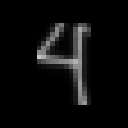

In [ ]:
import torch
import time
import numpy as np
from PIL import Image, ImageEnhance, ImageOps, ImageFilter
from google.colab import files
import os

# === PENGATURAN PATH MODEL ===
# Tentukan path model (sesuaikan jika direktori Anda berbeda)
base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'resnet18_mnist_baseline.pth')
quantized_path = os.path.join(base_dir, 'safetensors_models', 'resnet18_standard.safetensors')

# Memuat model berdasarkan path yang ditentukan
# Catatan: Kita asumsikan arsitekturnya adalah ResNet18 sesuai contoh path Anda
print(f"\u2302 Memuat baseline dari: {os.path.basename(baseline_path)}")
model_baseline = ResNet18().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])

print(f"\u2302 Memuat kuantisasi dari: {os.path.basename(quantized_path)}")
model_quant = load_ternary_safetensors(quantized_path, ResNet18()).to(device)
# =============================

def preprocess_final_v3_fixed(path, invert=True):
    img = Image.open(path).convert('L')
    if invert: img = ImageOps.invert(img)
    img = img.point(lambda p: 255 if p > 128 else 0)
    img = img.filter(ImageFilter.MaxFilter(3))
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)
    w, h = img.size
    ratio = 18.0 / max(w, h)
    new_size = (int(w * ratio), int(h * ratio))
    img = img.resize(new_size, Image.Resampling.LANCZOS)
    img = img.filter(ImageFilter.GaussianBlur(radius=0.6))
    final_img = Image.new('L', (28, 28), 0)
    final_img.paste(img, (int((28 - new_size[0]) / 2), int((28 - new_size[1]) / 2)))
    img_array = np.array(final_img, dtype=np.float32) / 255.0
    img_tensor = (img_array - 0.1307) / 0.3081
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device), final_img

def benchmark_inference(model, tensor, num_runs=100):
    model.eval()
    for _ in range(10): # Warmup
        with torch.no_grad():
            _ = model(tensor)
    if device.type == 'cuda': torch.cuda.synchronize()
    start = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(tensor)
    if device.type == 'cuda': torch.cuda.synchronize()
    end = time.time()
    avg_ms = ((end - start) / num_runs) * 1000
    fps = 1000 / avg_ms
    return avg_ms, fps

print("\n\u2302 Mengunggah gambar untuk inferensi & benchmark...")
uploaded = files.upload()
if uploaded:
    image_path = list(uploaded.keys())[0]
    input_tensor, processed_img = preprocess_final_v3_fixed(image_path, invert=True)

    # Jalankan Benchmark & Prediksi
    t_base, fps_base = benchmark_inference(model_baseline, input_tensor)
    with torch.no_grad():
        out_b = model_baseline(input_tensor)
        p_base = out_b.argmax().item()
        c_base = torch.nn.functional.softmax(out_b, dim=1)[0][p_base].item() * 100

    t_quant, fps_quant = benchmark_inference(model_quant, input_tensor)
    with torch.no_grad():
        out_q = model_quant(input_tensor)
        p_quant = out_q.argmax().item()
        c_quant = torch.nn.functional.softmax(out_q, dim=1)[0][p_quant].item() * 100

    print("\n" + "="*50)
    print(f"      PERBANDINGAN INFERENSI")
    print("="*50)
    print(f"\u2563 Baseline (FP32): {p_base} ({c_base:.1f}%) | {t_base:.3f} ms | {fps_base:.1f} FPS")
    print(f"\u2563 Kuantisasi FGQ: {p_quant} ({c_quant:.1f}%) | {t_quant:.3f} ms | {fps_quant:.1f} FPS")
    print("="*50)
    speedup = t_base / t_quant
    print(f"\u26a1 Speedup: {speedup:.2f}x")

    from IPython.display import display
    print("\n\u2388 Citra Input (28x28):")
    display(processed_img.resize((128, 128), Image.Resampling.NEAREST))

### LeNet-5

⌂ Memuat baseline dari: lenet5_mnist_baseline.pth
⌂ Memuat kuantisasi dari: lenet5_standard.safetensors

⌂ Mengunggah gambar untuk inferensi & benchmark...


Saving angka-4.jpg to angka-4 (10).jpg

      PERBANDINGAN INFERENSI
╣ Baseline (FP32): 4 (74.7%) | 0.469 ms | 2131.3 FPS
╣ Kuantisasi FGQ: 4 (25.1%) | 0.447 ms | 2237.0 FPS
⚡ Speedup: 1.05x

⎈ Citra Input (28x28):


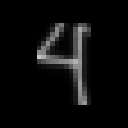

In [ ]:
import torch
import time
import numpy as np
from PIL import Image, ImageEnhance, ImageOps, ImageFilter
from google.colab import files
import os

# === PENGATURAN PATH MODEL ===
# Tentukan path model (sesuaikan jika direktori Anda berbeda)
base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'lenet5_mnist_baseline.pth')
quantized_path = os.path.join(base_dir, 'safetensors_models', 'lenet5_standard.safetensors')

# Memuat model berdasarkan path yang ditentukan
# Catatan: Kita asumsikan arsitekturnya adalah LeNet5 sesuai contoh path Anda
print(f"\u2302 Memuat baseline dari: {os.path.basename(baseline_path)}")
model_baseline = LeNet5().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])

print(f"\u2302 Memuat kuantisasi dari: {os.path.basename(quantized_path)}")
model_quant = load_ternary_safetensors(quantized_path, LeNet5()).to(device)
# =============================

def preprocess_final_v3_fixed(path, invert=True):
    img = Image.open(path).convert('L')
    if invert: img = ImageOps.invert(img)
    img = img.point(lambda p: 255 if p > 128 else 0)
    img = img.filter(ImageFilter.MaxFilter(3))
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)
    w, h = img.size
    ratio = 18.0 / max(w, h)
    new_size = (int(w * ratio), int(h * ratio))
    img = img.resize(new_size, Image.Resampling.LANCZOS)
    img = img.filter(ImageFilter.GaussianBlur(radius=0.6))
    final_img = Image.new('L', (28, 28), 0)
    final_img.paste(img, (int((28 - new_size[0]) / 2), int((28 - new_size[1]) / 2)))
    img_array = np.array(final_img, dtype=np.float32) / 255.0
    img_tensor = (img_array - 0.1307) / 0.3081
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device), final_img

def benchmark_inference(model, tensor, num_runs=100):
    model.eval()
    for _ in range(10): # Warmup
        with torch.no_grad():
            _ = model(tensor)
    if device.type == 'cuda': torch.cuda.synchronize()
    start = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(tensor)
    if device.type == 'cuda': torch.cuda.synchronize()
    end = time.time()
    avg_ms = ((end - start) / num_runs) * 1000
    fps = 1000 / avg_ms
    return avg_ms, fps

print("\n\u2302 Mengunggah gambar untuk inferensi & benchmark...")
uploaded = files.upload()
if uploaded:
    image_path = list(uploaded.keys())[0]
    input_tensor, processed_img = preprocess_final_v3_fixed(image_path, invert=True)

    # Jalankan Benchmark & Prediksi
    t_base, fps_base = benchmark_inference(model_baseline, input_tensor)
    with torch.no_grad():
        out_b = model_baseline(input_tensor)
        p_base = out_b.argmax().item()
        c_base = torch.nn.functional.softmax(out_b, dim=1)[0][p_base].item() * 100

    t_quant, fps_quant = benchmark_inference(model_quant, input_tensor)
    with torch.no_grad():
        out_q = model_quant(input_tensor)
        p_quant = out_q.argmax().item()
        c_quant = torch.nn.functional.softmax(out_q, dim=1)[0][p_quant].item() * 100

    print("\n" + "="*50)
    print(f"      PERBANDINGAN INFERENSI")
    print("="*50)
    print(f"\u2563 Baseline (FP32): {p_base} ({c_base:.1f}%) | {t_base:.3f} ms | {fps_base:.1f} FPS")
    print(f"\u2563 Kuantisasi FGQ: {p_quant} ({c_quant:.1f}%) | {t_quant:.3f} ms | {fps_quant:.1f} FPS")
    print("="*50)
    speedup = t_base / t_quant
    print(f"\u26a1 Speedup: {speedup:.2f}x")

    from IPython.display import display
    print("\n\u2388 Citra Input (28x28):")
    display(processed_img.resize((128, 128), Image.Resampling.NEAREST))